<a href="https://colab.research.google.com/github/karabeyseren-sys/CS-WinMet5-Trade-Botu/blob/main/Ilk_strateji_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

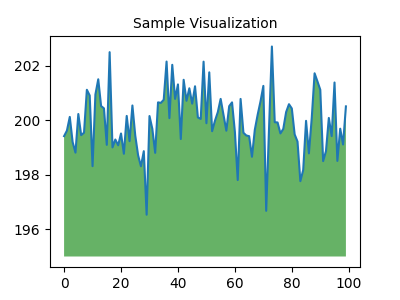

In [ ]:
import numpy as np
import IPython.display as displaydisplay
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Veriler yükleniyor ve SMC/ICT analizleri yapılıyor...
--------------------------------------------------
🚀 SMC/ICT FİLTRELİ YENİ STRATEJİ SONUÇLARI 🚀
--------------------------------------------------
Toplam Alınan Mantıklı İşlem: 22
TP Vuran (Kazanan): 20
SL Vuran (Kaybeden): 2
Kazanma Oranı (Win Rate): %90.91
Net Kâr (1 Ons İçin): $0.00
--------------------------------------------------


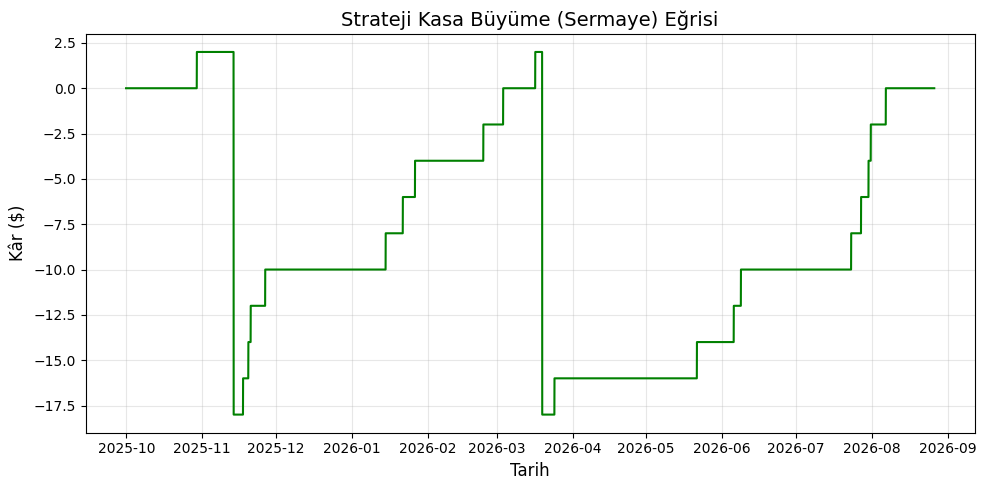

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Veriler yükleniyor ve SMC/ICT analizleri yapılıyor...")

# 1. VERİ YÜKLEME (15 Dakikalık Veri)
df = pd.read_csv('OANDA_XAUUSD, 15.csv')

# TradingView 'Unnamed' boş sütunlarını temizleme
df = df.loc[:, ~df.columns.str.contains('Unnamed')]

# Zamanı ayarla (Grafik çizimi için önemli)
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)

    # 2. SMC / ICT KONSEPTLERİNİ MATEMATİĞE DÖKME

    # A. Zaman Filtresi (Silver Bullet / Hacim Saatleri)
    # Sadece Londra ve New York seans kesişimlerinde (Örn: TSİ 14:00 - 18:00 arası) işlem yap.
    df['Saat'] = df.index.hour
    df['Silver_Bullet_Penceresi'] = df['Saat'].between(14, 18)

    # B. Likidite Temizliği (Liquidity Sweep / Judas Swing)
    # Fiyatın son 4 saatin (15m grafikte 16 mum) en düşük seviyesinin altına inip (stop patlatıp), o mumu yeşil kapatması.
    df['Son_4s_Dip'] = df['low'].rolling(window=16).min().shift(1)
    df['Likidite_Avi'] = (df['low'] < df['Son_4s_Dip']) & (df['close'] > df['open'])

    # C. Fair Value Gap (FVG) - Yükseliş Yönlü
    # 3 mumluk yapıda: 1. mumun tepesi ile 3. mumun dibi arasında fiyat boşluğu olması
    df['FVG_Var'] = df['low'] > df['high'].shift(2)

    # Botun orijinal sinyal kolonu
    if 'Buy' in df.columns:
        df['Buy'] = df['Buy'].fillna(0)
    else:
        df['Buy'] = 0

    # 3. YENİ KUSURSUZ GİRİŞ STRATEJİSİ (Filtrelerin Birleşimi)
    # İşlem Şartı: Bot 'Buy' diyecek VE (Likidite alınmış olacak VEYA FVG olacak) VE Doğru saatte olacağız.
    df['Kesin_Giris'] = (df['Buy'] > 0) & (df['Silver_Bullet_Penceresi']) & (df['Likidite_Avi'] | df['FVG_Var'])

    # 4. GÜVENLİ BACKTEST (Kasa Patlamasını Önleyen SL Eklenmiş Hal)
    TP_AMOUNT = 2.0  # Kar Al (2 Dolar)
    SL_AMOUNT = 20.0 # Zarar Kes (20 Dolar) - Kasa güvenliği için şart!

    open_trades = []
    closed_trades = []
    kasa_gecmisi = [] # Grafiğini çizmek için
    toplam_kar = 0

    for index, row in df.iterrows():
        current_high = row['high']
        current_low = row['low']

        trades_to_keep = []
        for trade in open_trades:
            # Önce SL (Zarar Kes) kontrolü - Fiyat 20 dolar düştü mü?
            if trade['entry_price'] - current_low >= SL_AMOUNT:
                trade['profit'] = -SL_AMOUNT
                closed_trades.append(trade)
                toplam_kar -= SL_AMOUNT
            # Sonra TP (Kar Al) kontrolü - Fiyat 2 dolar çıktı mı?
            elif current_high >= trade['entry_price'] + TP_AMOUNT:
                trade['profit'] = TP_AMOUNT
                closed_trades.append(trade)
                toplam_kar += TP_AMOUNT
            else:
                trades_to_keep.append(trade)

        open_trades = trades_to_keep

        # Yeni Giriş Sinyali
        if row['Kesin_Giris']:
            open_trades.append({'entry_price': row['close']})

        kasa_gecmisi.append(toplam_kar)

    df['Kasa'] = kasa_gecmisi

    # 5. İSTATİSTİKLERİ YAZDIRMA
    toplam_islem = len(closed_trades)
    if toplam_islem > 0:
        kazananlar = len([t for t in closed_trades if t['profit'] > 0])
        kaybedenler = toplam_islem - kazananlar
        win_rate = (kazananlar / toplam_islem) * 100

        print("-" * 50)
        print("🚀 SMC/ICT FİLTRELİ YENİ STRATEJİ SONUÇLARI 🚀")
        print("-" * 50)
        print(f"Toplam Alınan Mantıklı İşlem: {toplam_islem}")
        print(f"TP Vuran (Kazanan): {kazananlar}")
        print(f"SL Vuran (Kaybeden): {kaybedenler}")
        print(f"Kazanma Oranı (Win Rate): %{win_rate:.2f}")
        print(f"Net Kâr (1 Ons İçin): ${toplam_kar:.2f}")
        print("-" * 50)

        # 6. SERMAYE BÜYÜME GRAFİĞİNİ ÇİZME
        plt.figure(figsize=(10, 5))
        plt.plot(df.index, df['Kasa'], color='green', linewidth=1.5)
        plt.title('Strateji Kasa Büyüme (Sermaye) Eğrisi', fontsize=14)
        plt.xlabel('Tarih', fontsize=12)
        plt.ylabel('Kâr ($)', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Bu sıkı filtrelere uyan hiçbir işlem bulunamadı. Filtreleri esnetebiliriz.")
else:
    print("Hata: 'time' sütunu bulunamadı. Zaman bazlı analizler yapılamıyor.")
